<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Trial/blob/main/A_Hybrid_EfficientNetV2B0%E2%80%93Transformer_Model_for_Automated_Arsenicosis_Detection_from_Skin_Images_Using_Group_Aware_Cross_Validation(_).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

from sklearn.model_selection import GroupKFold
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

from sklearn.calibration import calibration_curve

from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy(
    'mixed_float16'
)

In [2]:
import shutil
import os

if not os.path.exists("/content/dataset"):
    shutil.copytree(
        "/content/drive/MyDrive/ArsenicSkinImageBD/Augmented",
        "/content/dataset"
    )

In [3]:
DATASET_PATH = "/content/dataset"
IMG_SIZE = (224,224)
BATCH_SIZE = 32
N_SPLITS = 5

In [4]:
os.makedirs(
    "/content/drive/MyDrive/arsenicosis_models",
    exist_ok=True
)

In [5]:
data = []

for label in ["infected", "not_infected"]:

    folder = os.path.join(DATASET_PATH, label)

    for file in os.listdir(folder):

        if file.endswith(".png"):

            filepath = os.path.join(folder, file)

            group_id = file.split("_augmented_")[0]

            data.append(
                [filepath, label, group_id]
            )

df = pd.DataFrame(
    data,
    columns=[
        "filepath",
        "label",
        "group"
    ]
)

In [6]:
def transformer_block(x):

    attn = layers.MultiHeadAttention(
        num_heads=4,
        key_dim=x.shape[-1] // 4
    )(x, x)

    x1 = layers.Add()([x, attn])

    x1 = layers.LayerNormalization()(x1)

    ffn = layers.Dense(
        x.shape[-1] * 2,
        activation="gelu"
    )(x1)

    ffn = layers.Dense(
        x.shape[-1]
    )(ffn)

    x2 = layers.Add()([x1, ffn])

    x2 = layers.LayerNormalization()(x2)

    return x2

In [7]:
def build_model():

    inputs = layers.Input(
        shape=(224,224,3)
    )

    base = tf.keras.applications.EfficientNetV2B0(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs
    )

    base.trainable = True

    for layer in base.layers[:-20]:
        layer.trainable = False

    x = base.output

    h,w,c = x.shape[1], x.shape[2], x.shape[3]

    patches = h*w

    x = layers.Reshape(
        (patches,c)
    )(x)

    pos = tf.range(
        start=0,
        limit=patches,
        delta=1
    )

    pos_emb = layers.Embedding(
        patches,
        c
    )(pos)

    x = x + pos_emb

    x = transformer_block(x)
    x = transformer_block(x)

    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(
        512,
        activation="relu"
    )(x)

    x = layers.Dropout(0.4)(x)

    x = layers.Dense(
        256,
        activation="relu"
    )(x)

    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(
    2,
    activation="softmax",
    dtype="float32"
    )(x)

    model = models.Model(
        inputs,
        outputs
    )

    return model

In [8]:
gkf = GroupKFold(
    n_splits=N_SPLITS
)

fold_accuracies = []
fold_losses = []

histories = []

mean_fpr = np.linspace(
    0,
    1,
    100
)

tprs = []
aucs = []

all_y_true = []
all_y_pred = []
all_probs = []

for fold, (train_idx, val_idx) in enumerate(

    gkf.split(
        df,
        df["label"],
        groups=df["group"]
    ),

    start=1
):

    print("\n" + "="*50)
    print(f"Starting Fold {fold}/{N_SPLITS}")
    print("="*50)

    train_df = df.iloc[
        train_idx
    ]

    val_df = df.iloc[
        val_idx
    ]

    print(
        f"Fold {fold}: Train={len(train_df)}, Validation={len(val_df)}"
    )

    print(
        train_df["group"].nunique(),
        val_df["group"].nunique()
    )

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=40,
        zoom_range=0.3,
        horizontal_flip=True,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2
    )

    val_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input
    )

    train_generator = train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col="filepath",
        y_col="label",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=True
    )

    val_generator = val_datagen.flow_from_dataframe(
        dataframe=val_df,
        x_col="filepath",
        y_col="label",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False
    )

    labels = train_generator.classes

    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(labels),
        y=labels
    )

    class_weights = dict(
        enumerate(class_weights)
    )

    model = build_model()

    if fold == 1:
        model.summary()

    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=1e-4,
            weight_decay=1e-4
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    callbacks_list = [

        callbacks.ModelCheckpoint(
    f"/content/drive/MyDrive/arsenicosis_models/best_fold_{fold}.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
    ),

        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        ),

        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        )
    ]

    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=10,
        class_weight=class_weights,
        callbacks=callbacks_list
    )

    histories.append(
        history
    )

    model.load_weights(
        f"/content/drive/MyDrive/arsenicosis_models/best_fold_{fold}.keras"
    )

    loss, accuracy = model.evaluate(
        val_generator,
        verbose=0
    )

    print(
        f"Fold {fold} Accuracy = {accuracy*100:.6f}%"
    )

    print(
        f"Fold {fold} Loss = {loss:.6f}"
    )

    fold_accuracies.append(
        accuracy * 100
    )

    fold_losses.append(
        loss
    )

    y_true = val_generator.classes

    y_pred = model.predict(
        val_generator,
        verbose=0
    )

    y_pred_prob = y_pred[:,1]

    y_pred_class = np.argmax(
        y_pred,
        axis=1
    )

    all_y_true.extend(
        y_true
    )

    all_y_pred.extend(
        y_pred_class
    )

    all_probs.extend(
        y_pred_prob
    )

    fpr, tpr, _ = roc_curve(
        y_true,
        y_pred_prob
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    interp_tpr = np.interp(
        mean_fpr,
        fpr,
        tpr
    )

    interp_tpr[0] = 0.0

    tprs.append(
        interp_tpr
    )

    aucs.append(
        roc_auc
    )

print("\n")
print("="*50)
print("Cross Validation Results")
print("="*50)

for i, score in enumerate(
    fold_accuracies,
    start=1
):
    print(
        f"Fold {i}: {score:.2f}%"
    )

print(
    "\nAverage Accuracy:",
    np.mean(fold_accuracies)
)

print(
    "Standard Deviation:",
    np.std(fold_accuracies)
)

print(
    "\nAverage Loss:",
    np.mean(fold_losses)
)


Starting Fold 1/5
Fold 1: Train=7110, Validation=1782
1185 297
Found 7110 validated image filenames belonging to 2 classes.
Found 1782 validated image filenames belonging to 2 classes.
24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 32,949,586 (125.69 MB)

 Trainable params: 27,848,114 (106.23 MB)

 Non-trainable params: 5,101,472 (19.46 MB)

Epoch 1/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 677ms/step - accuracy: 0.8342 - loss: 0.3651
Epoch 1: val_accuracy improved from None to 0.96465, saving model to /content/drive/MyDrive/arsenicosis_models/best_fold_1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/arsenicosis_models/best_fold_1.keras
223/223 ━━━━━━━━━━━━━━━━━━━━ 315s 1s/step - accuracy: 0.8937 - loss: 0.2600 - val_accuracy: 0.9646 - val_loss: 0.0983 - learning_rate: 1.0000e-04
Epoch 2/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.9529 - loss: 0.1370
Epoch 2: val_accuracy improved from 0.96465 to 0.98316, saving model to /content/drive/MyDrive/arsenicosis_models/best_fold_1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/arsenicosis_models/best_fold_1.keras
223/223 ━━━━━━━━━━━━━━━━━━━━ 134s 601ms/step - accuracy: 0.9574 - loss: 0.1240 - val_accuracy: 0.9832 - val_loss: 0.0467 - learning_rate: 1.0000e-04
Epoch 3/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.9682 - los

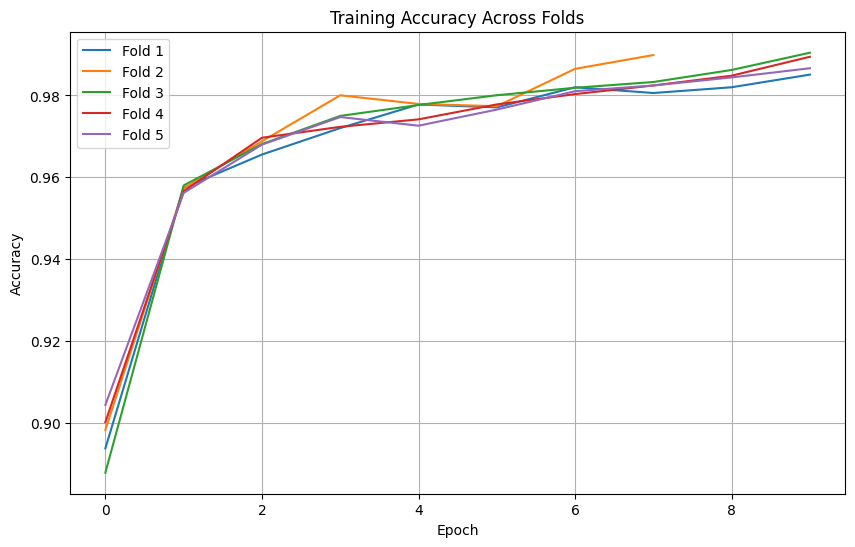

In [9]:
plt.figure(figsize=(10,6))

for i, history in enumerate(histories):
    plt.plot(
        history.history["accuracy"],
        label=f"Fold {i+1}"
    )

plt.title(
    "Training Accuracy Across Folds"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

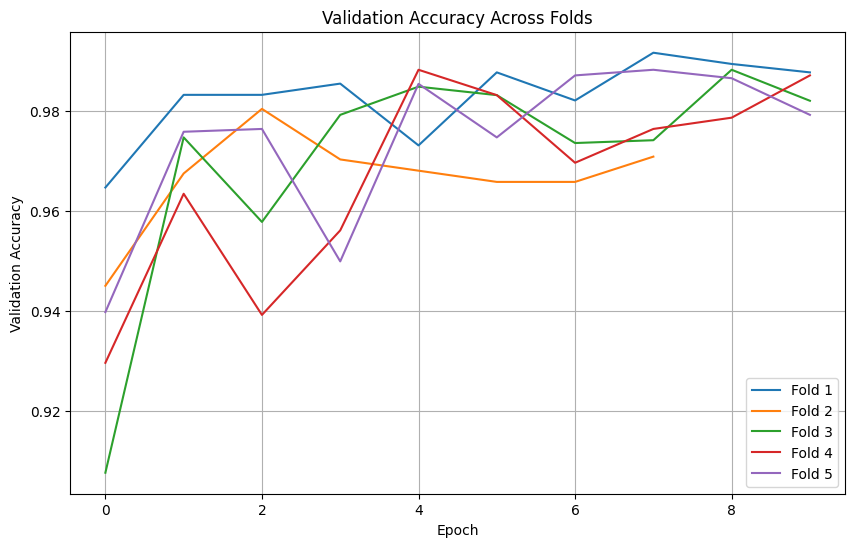

In [10]:
plt.figure(figsize=(10,6))

for i, history in enumerate(histories):
    plt.plot(
        history.history["val_accuracy"],
        label=f"Fold {i+1}"
    )

plt.title(
    "Validation Accuracy Across Folds"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Validation Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

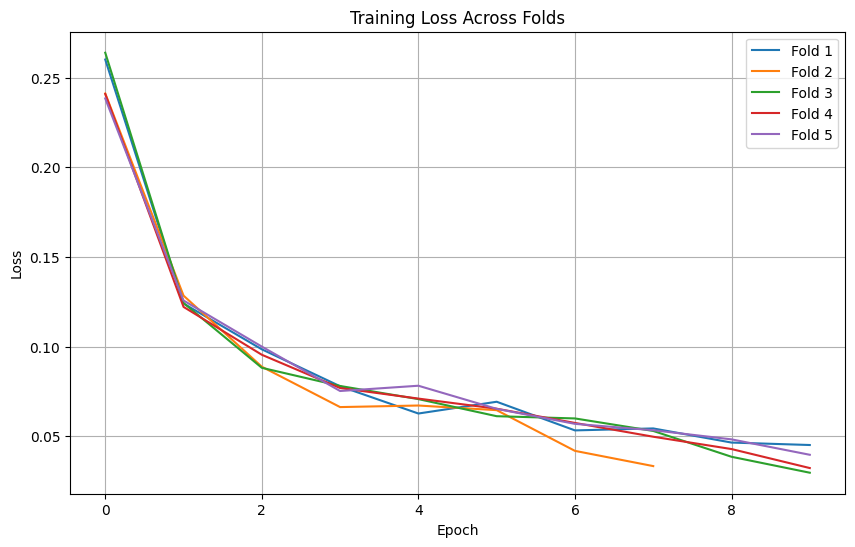

In [11]:
plt.figure(figsize=(10,6))

for i, history in enumerate(histories):
    plt.plot(
        history.history["loss"],
        label=f"Fold {i+1}"
    )

plt.title(
    "Training Loss Across Folds"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.legend()

plt.grid(True)

plt.show()

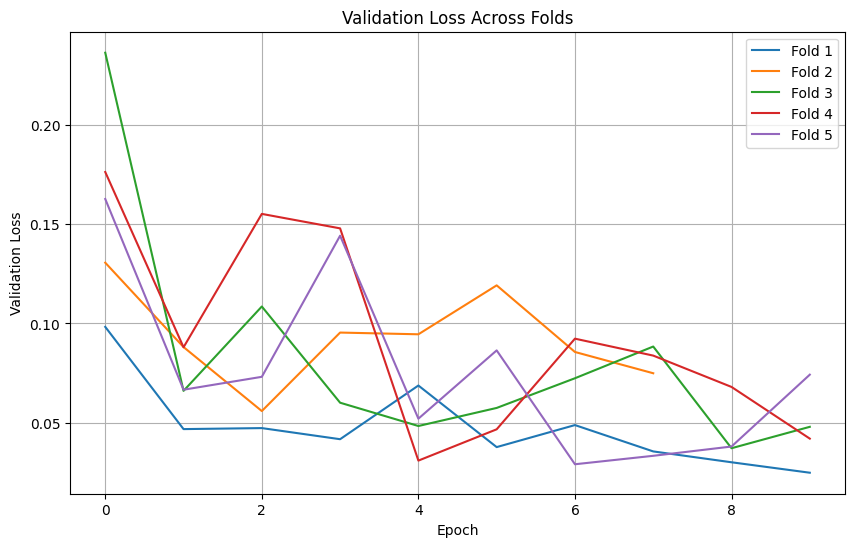

In [12]:
plt.figure(figsize=(10,6))

for i, history in enumerate(histories):
    plt.plot(
        history.history["val_loss"],
        label=f"Fold {i+1}"
    )

plt.title(
    "Validation Loss Across Folds"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Validation Loss"
)

plt.legend()

plt.grid(True)

plt.show()

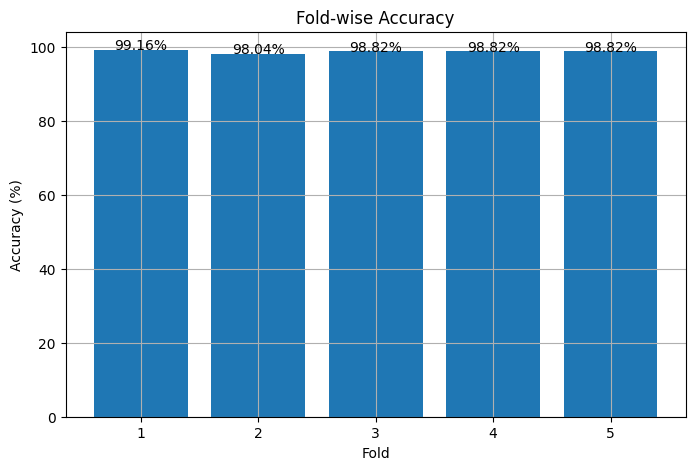

In [13]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    range(1, len(fold_accuracies)+1),
    fold_accuracies
)

plt.xlabel("Fold")
plt.ylabel("Accuracy (%)")
plt.title("Fold-wise Accuracy")
plt.xticks(range(1, len(fold_accuracies)+1))

for bar, value in zip(
    bars,
    fold_accuracies
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.1,
        f"{value:.2f}%",
        ha="center"
    )

plt.grid(True)
plt.show()

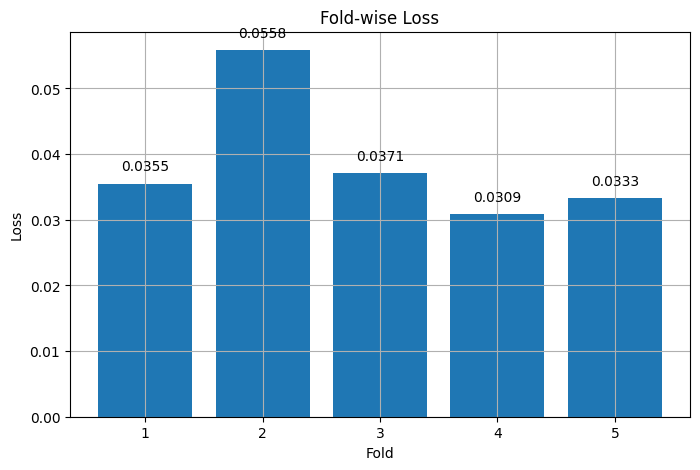

In [14]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    range(1, len(fold_losses)+1),
    fold_losses
)

plt.xlabel("Fold")
plt.ylabel("Loss")
plt.title("Fold-wise Loss")
plt.xticks(range(1, len(fold_losses)+1))

for bar, value in zip(
    bars,
    fold_losses
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.002,
        f"{value:.4f}",
        ha="center"
    )

plt.grid(True)
plt.show()

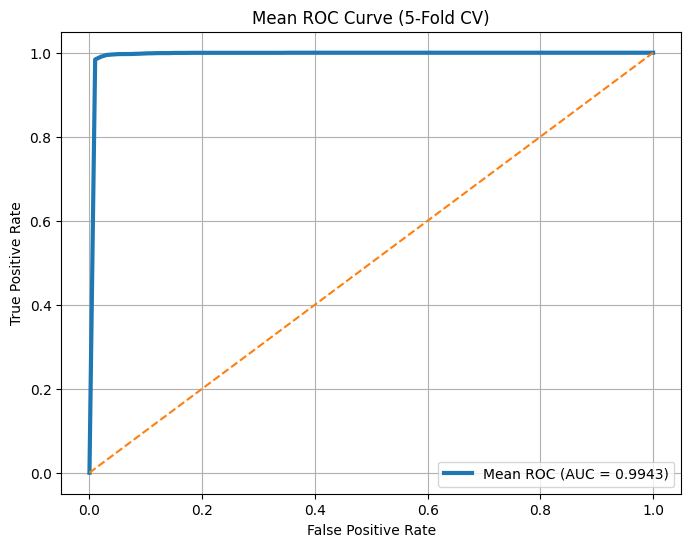

In [15]:
mean_tpr = np.mean(
    tprs,
    axis=0
)

mean_tpr[-1] = 1.0

mean_auc = auc(
    mean_fpr,
    mean_tpr
)

plt.figure(figsize=(8,6))

plt.plot(
    mean_fpr,
    mean_tpr,
    linewidth=3,
    label=f"Mean ROC (AUC = {mean_auc:.4f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Mean ROC Curve (5-Fold CV)")
plt.legend()
plt.grid(True)

plt.show()

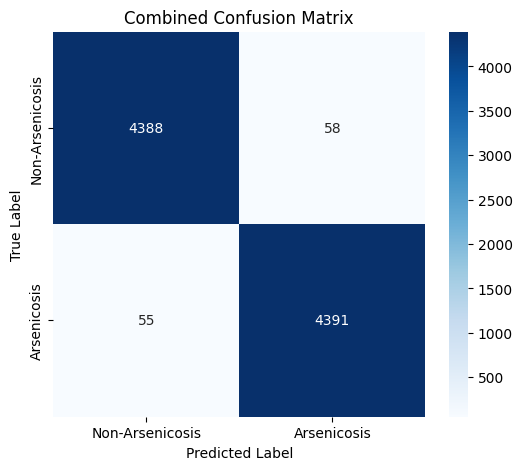

In [16]:
cm = confusion_matrix(
    all_y_true,
    all_y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Arsenicosis","Arsenicosis"],
    yticklabels=["Non-Arsenicosis","Arsenicosis"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Combined Confusion Matrix")

plt.show()

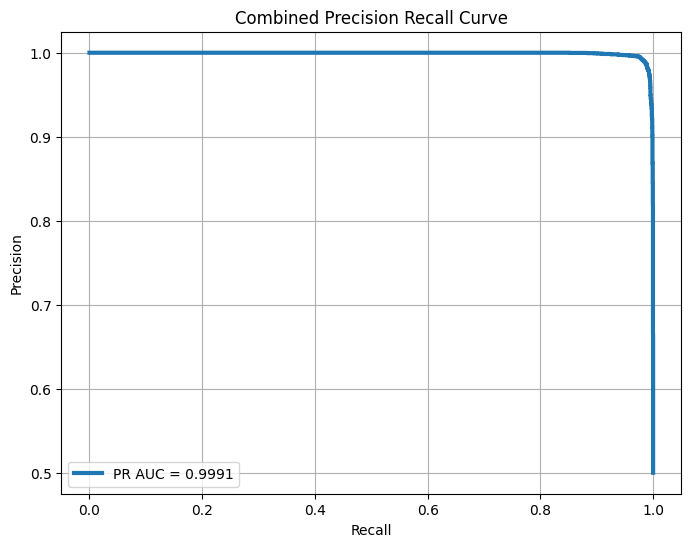

In [17]:
precision, recall, _ = precision_recall_curve(
    all_y_true,
    all_probs
)

pr_auc = auc(
    recall,
    precision
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    linewidth=3,
    label=f"PR AUC = {pr_auc:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Combined Precision Recall Curve")
plt.legend()
plt.grid(True)

plt.show()

In [18]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(
    all_y_true,
    all_y_pred
)

precision = precision_score(
    all_y_true,
    all_y_pred
)

recall = recall_score(
    all_y_true,
    all_y_pred
)

f1 = f1_score(
    all_y_true,
    all_y_pred
)

print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1 Score  : {f1*100:.2f}%")

Accuracy  : 98.73%
Precision : 98.70%
Recall    : 98.76%
F1 Score  : 98.73%


In [19]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_y_true,
        all_y_pred,
        target_names=[
            "Non-Arsenicosis",
            "Arsenicosis"
        ]
    )
)

                 precision    recall  f1-score   support

Non-Arsenicosis       0.99      0.99      0.99      4446
    Arsenicosis       0.99      0.99      0.99      4446

       accuracy                           0.99      8892
      macro avg       0.99      0.99      0.99      8892
   weighted avg       0.99      0.99      0.99      8892



In [20]:
tn, fp, fn, tp = confusion_matrix(
    all_y_true,
    all_y_pred
).ravel()

specificity = tn / (tn + fp)

print(
    f"Specificity: {specificity*100:.2f}%"
)

Specificity: 98.70%
